# Learnify Overview

This notebook introduces the outer public surface of **Learnify**, a didactic machine learning and deep learning library built from scratch with raw Python and NumPy.

The focus here is practical and visual:

- scalar autodiff and computation graphs
- gradient-descent linear models
- decision trees and random forests
- clustering algorithms
- a tiny MLP built on backpropagation
- reusable plotting helpers for every model family

The project is still growing, but the current core is already large enough to study end to end.

## 1. Setup

Import the package, enable a compact plot style, and inspect the top-level API.

In [1]:
from pprint import pprint

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

import learnify
from learnify import (
    AgglomerativeClustering,
    DecisionTreeClassifier,
    KMeans,
    LinearRegressionGD,
    LinearSVM,
    LogisticRegressionGD,
    MLP,
    RandomForestClassifier,
    Value,
    computation_graph_svg,
    mean_squared_error,
    plotting,
    r2_score,
)

np.set_printoptions(precision=3, suppress=True)
plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (6.5, 4.5),
        "axes.facecolor": "#fcfcff",
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.18,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

pprint(sorted(learnify.__all__))

['AgglomerativeClustering',
 'DecisionTreeClassifier',
 'GradientDescentOptimizer',
 'KMeans',
 'LinearRegressionGD',
 'LinearSVM',
 'LogisticRegressionGD',
 'MLP',
 'RandomForestClassifier',
 'Value',
 'accuracy_score',
 'computation_graph_dot',
 'computation_graph_svg',
 'gradient_descent_step',
 'mean_squared_error',
 'plotting',
 'r2_score',
 'rng',
 'save_computation_graph_svg',
 'trace_graph']


## 2. Autodiff and computation-graph visualization

`Value` is the smallest learning primitive in the library. Each scalar stores its numeric value, its gradient, and links to the nodes that created it. After `backward()`, Learnify can render the full computation graph with values and gradients at every node.

x | data=2.0000 | grad=-0.2120 | op=leaf
y | data=-3.0000 | grad=0.1413 | op=leaf
(anon) | data=-6.0000 | grad=0.0707 | op=*
b | data=4.0000 | grad=0.0707 | op=leaf
(anon) | data=-2.0000 | grad=0.0707 | op=+
score | data=-0.9640 | grad=1.0000 | op=tanh


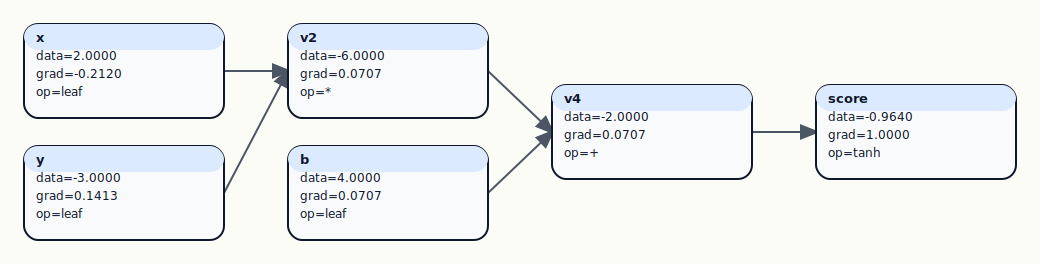

In [2]:
x = Value(2.0, label="x")
y = Value(-3.0, label="y")
b = Value(4.0, label="b")

score = ((x * y) + b).tanh()
score.label = "score"
score.backward()

for node in score.topo():
    print(f"{node.label or '(anon)'} | data={node.data:.4f} | grad={node.grad:.4f} | op={node._op or 'leaf'}")

display(SVG(computation_graph_svg(score)))

## 3. Linear regression

The regression model is trained with full-batch gradient descent. Below, we plot the fitted line, the learned coefficients, and the optimization curve.

weights: [2.]
bias: 1.0
mse: 0.0
r2: 1.0


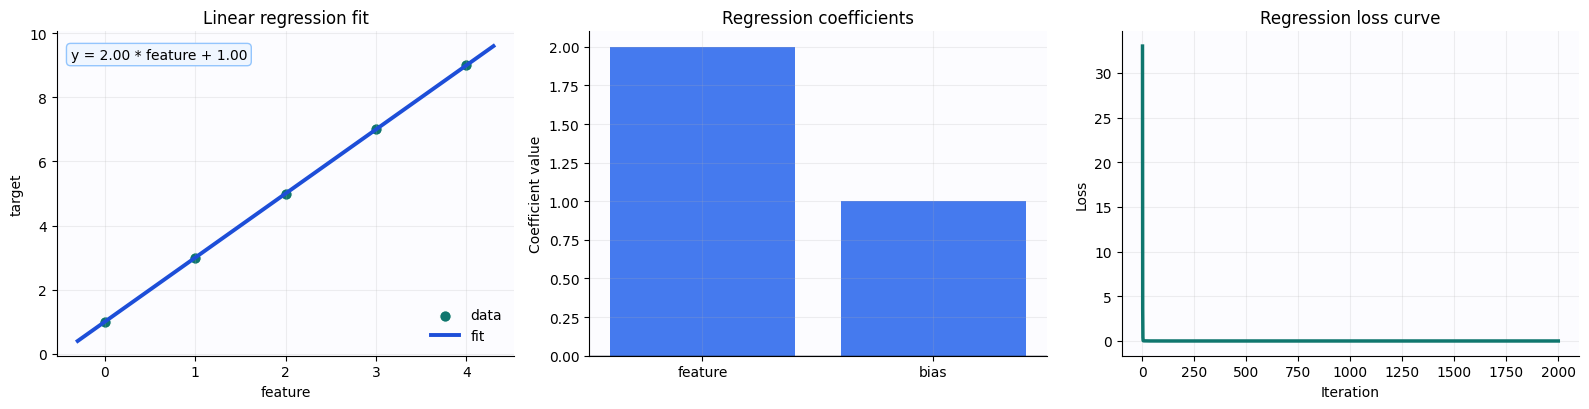

In [3]:
X_reg = np.array([[0.0], [1.0], [2.0], [3.0], [4.0]])
y_reg = np.array([1.0, 3.0, 5.0, 7.0, 9.0])

linreg = LinearRegressionGD(learning_rate=0.05, n_iterations=2_000)
linreg.fit(X_reg, y_reg)
reg_predictions = linreg.predict(X_reg)

print("weights:", linreg.weights_)
print("bias:", round(linreg.bias_, 4))
print("mse:", round(mean_squared_error(y_reg, reg_predictions), 6))
print("r2:", round(r2_score(y_reg, reg_predictions), 6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plotting.plot_regression_fit(linreg, X_reg, y_reg, ax=axes[0], feature_name="feature", target_name="target")
plotting.plot_linear_coefficients(linreg, ax=axes[1], feature_names=["feature"], title="Regression coefficients")
plotting.plot_loss_curve(linreg.loss_history_, ax=axes[2], title="Regression loss curve")
fig.tight_layout()
plt.show()

## 4. Logistic regression

For binary classification, it is useful to visualize both the probability field and the **discriminant function** `w·x + b`. The boundary itself is the zero contour of the discriminant, or equivalently the `0.5` contour after the sigmoid.

predictions: [0 0 0 1 1 1]
probabilities:
 [[1.    0.   ]
 [1.    0.   ]
 [0.994 0.006]
 [0.005 0.995]
 [0.    1.   ]
 [0.    1.   ]]
discriminant values: [-10.663  -8.906  -5.072   5.312   8.77   13.043]


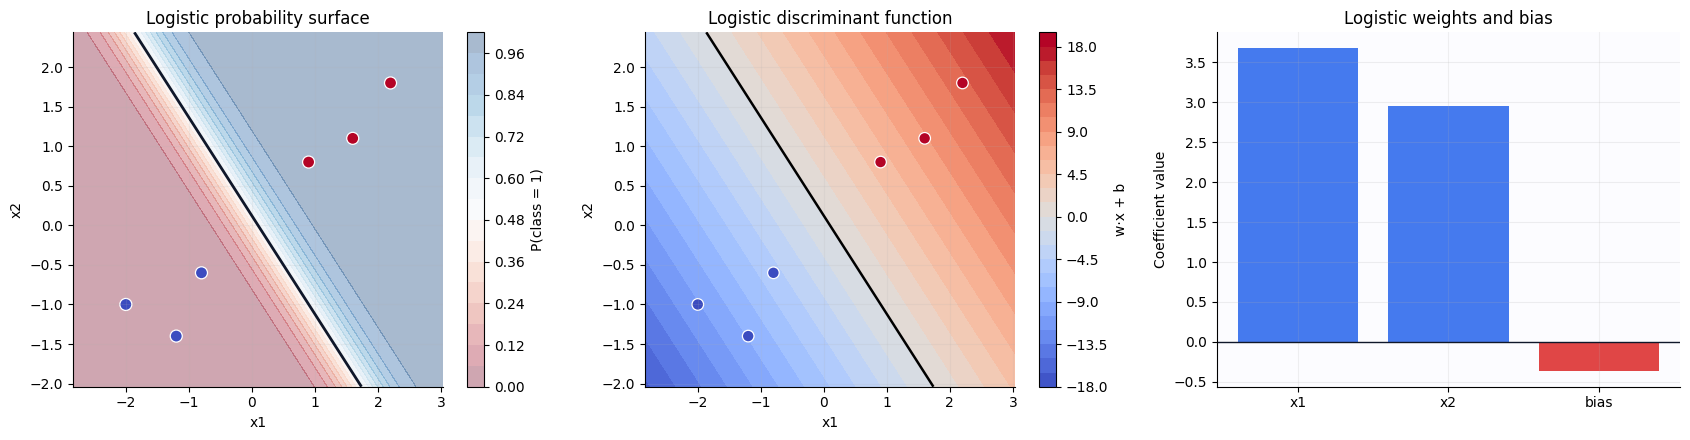

In [4]:
X_cls = np.array([
    [-2.0, -1.0],
    [-1.2, -1.4],
    [-0.8, -0.6],
    [0.9, 0.8],
    [1.6, 1.1],
    [2.2, 1.8],
])
y_cls = np.array([0, 0, 0, 1, 1, 1])

logreg = LogisticRegressionGD(learning_rate=0.2, n_iterations=2_000)
logreg.fit(X_cls, y_cls)

print("predictions:", logreg.predict(X_cls))
print("probabilities:\n", np.round(logreg.predict_proba(X_cls), 3))
print("discriminant values:", np.round(logreg.decision_function(X_cls), 3))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
plotting.plot_binary_decision_surface(
    logreg,
    X_cls,
    y_cls,
    ax=axes[0],
    feature_names=["x1", "x2"],
    response="probability",
    title="Logistic probability surface",
)
plotting.plot_discriminant_function(
    logreg,
    X_cls,
    y_cls,
    ax=axes[1],
    feature_names=["x1", "x2"],
    title="Logistic discriminant function",
)
plotting.plot_linear_coefficients(
    logreg,
    ax=axes[2],
    feature_names=["x1", "x2"],
    title="Logistic weights and bias",
)
fig.tight_layout()
plt.show()

## 5. Linear SVM

The SVM section uses the same idea, but the geometry is sharper: the discriminant function directly defines the separating hyperplane, and the `±1` contours correspond to the margins.

predictions: [0 0 0 1 1 1]
discriminant values: [-2.099 -1.76  -1.015  1.001  1.672  2.502]


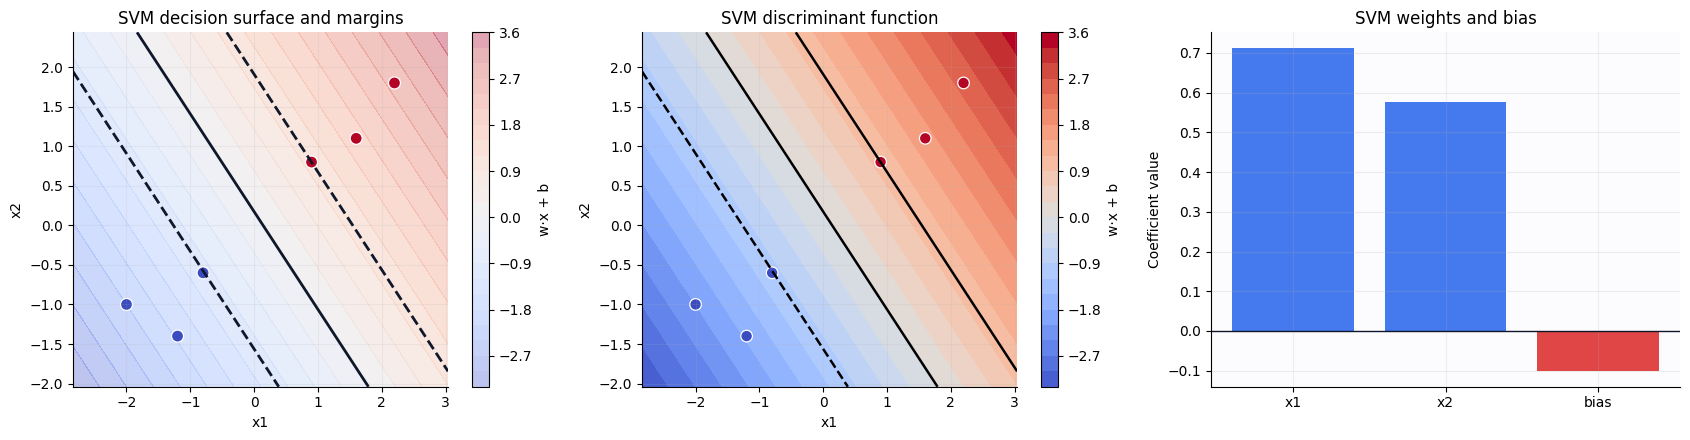

In [5]:
svm = LinearSVM(learning_rate=0.05, regularization=0.01, epochs=2_000)
svm.fit(X_cls, y_cls)

print("predictions:", svm.predict(X_cls))
print("discriminant values:", np.round(svm.decision_function(X_cls), 3))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
plotting.plot_binary_decision_surface(
    svm,
    X_cls,
    y_cls,
    ax=axes[0],
    feature_names=["x1", "x2"],
    response="decision",
    title="SVM decision surface and margins",
)
plotting.plot_discriminant_function(
    svm,
    X_cls,
    y_cls,
    ax=axes[1],
    feature_names=["x1", "x2"],
    title="SVM discriminant function",
)
plotting.plot_linear_coefficients(
    svm,
    ax=axes[2],
    feature_names=["x1", "x2"],
    title="SVM weights and bias",
)
fig.tight_layout()
plt.show()

## 6. Decision tree

A didactic tree should be readable. Learnify now exposes enough internal structure to draw the tree itself and a feature-importance summary based on normalized impurity decrease.

predictions: [0 0 1 1 2 2]
feature importances: [1. 0.]
tree depth: 2
leaf count: 3


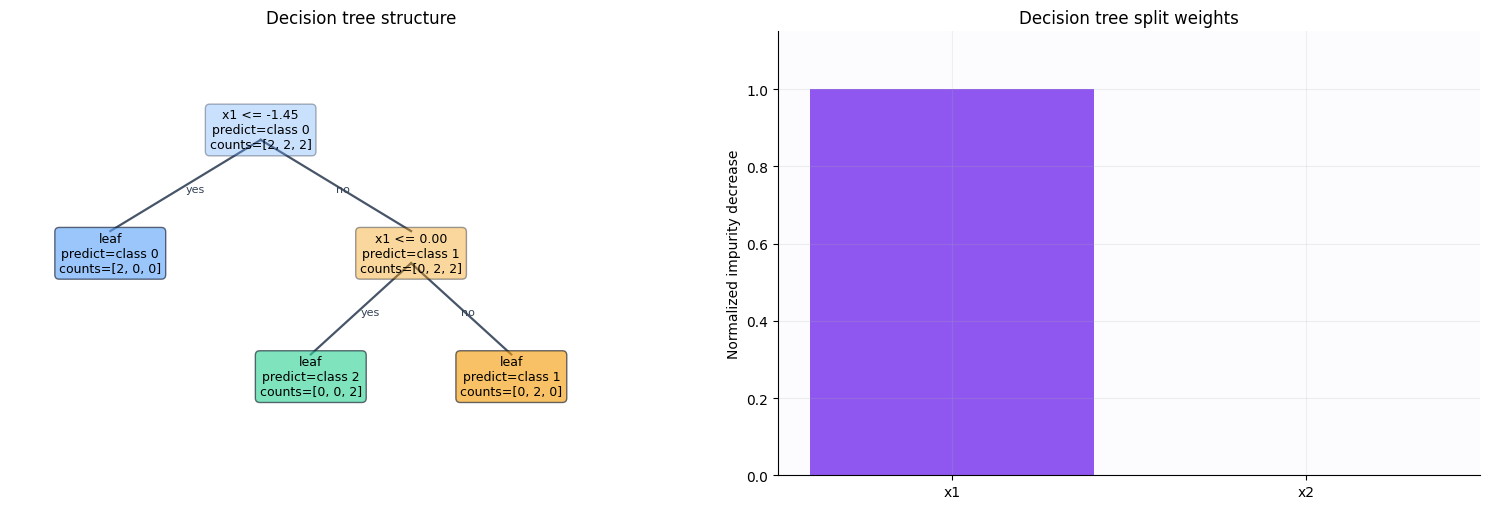

In [6]:
X_tree = np.array([
    [-2.0, -1.0],
    [-1.5, -0.3],
    [1.0, 2.0],
    [1.4, 1.5],
    [-1.0, 1.5],
    [-1.4, 2.0],
])
y_tree = np.array([0, 0, 1, 1, 2, 2])

tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_tree, y_tree)

print("predictions:", tree.predict(X_tree))
print("feature importances:", np.round(tree.feature_importances_, 3))
print("tree depth:", tree.depth_)
print("leaf count:", tree.n_leaves_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
plotting.plot_decision_tree(
    tree,
    ax=axes[0],
    feature_names=["x1", "x2"],
    class_names=["class 0", "class 1", "class 2"],
    title="Decision tree structure",
)
plotting.plot_tree_feature_importances(
    tree,
    ax=axes[1],
    feature_names=["x1", "x2"],
    title="Decision tree split weights",
)
fig.tight_layout()
plt.show()

## 7. Random forest

For the forest, the notebook shows multiple learned trees together with the average feature importance across the ensemble.

forest predictions: [0 0 1 1 2 2]
average feature importances: [0.592 0.408]


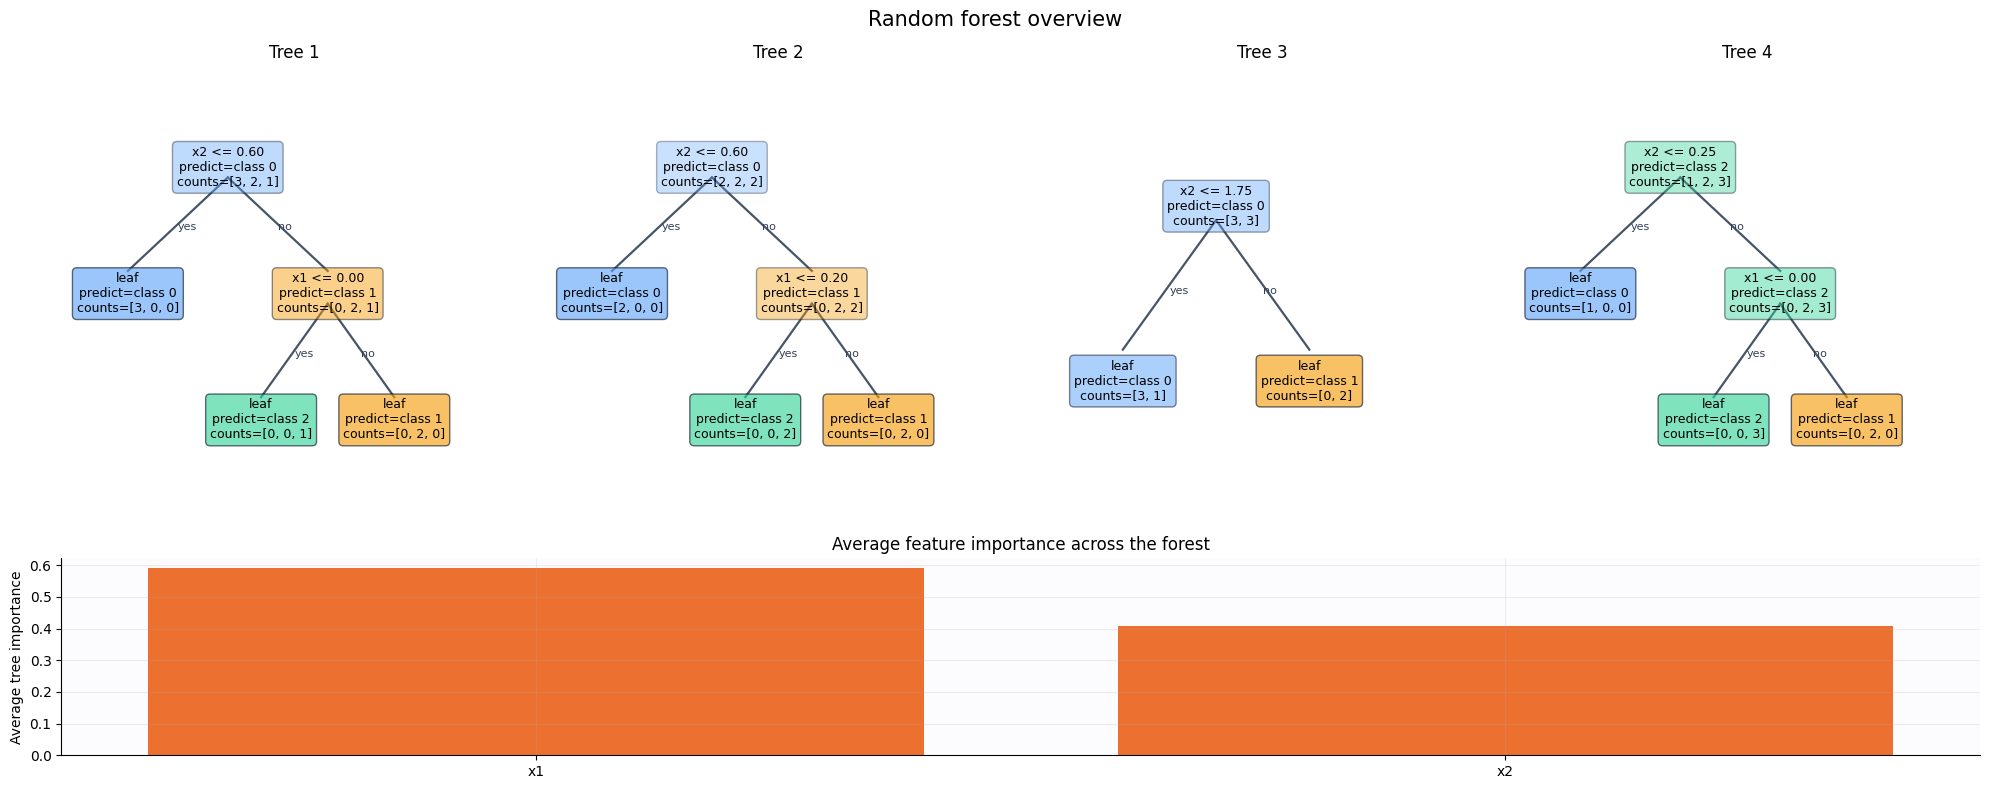

In [7]:
forest = RandomForestClassifier(n_estimators=12, max_depth=4, random_state=0)
forest.fit(X_tree, y_tree)

print("forest predictions:", forest.predict(X_tree))
print("average feature importances:", np.round(forest.feature_importances_, 3))

plotting.plot_random_forest(
    forest,
    feature_names=["x1", "x2"],
    class_names=["class 0", "class 1", "class 2"],
    max_trees=4,
    title="Random forest overview",
)
plt.show()

## 8. Clustering

The clustering section combines a partitioning method and a hierarchical method. For agglomerative clustering, the notebook also renders a merge diagram so the hierarchy is visible, not just the final labels.

KMeans labels: [1 1 1 0 0 0]
KMeans centers:
 [[5.033 5.067]
 [0.1   0.   ]]
Agglomerative labels: [0 0 0 1 1 1]
Agglomerative merge distances: [0.141 0.141 0.212 0.354]


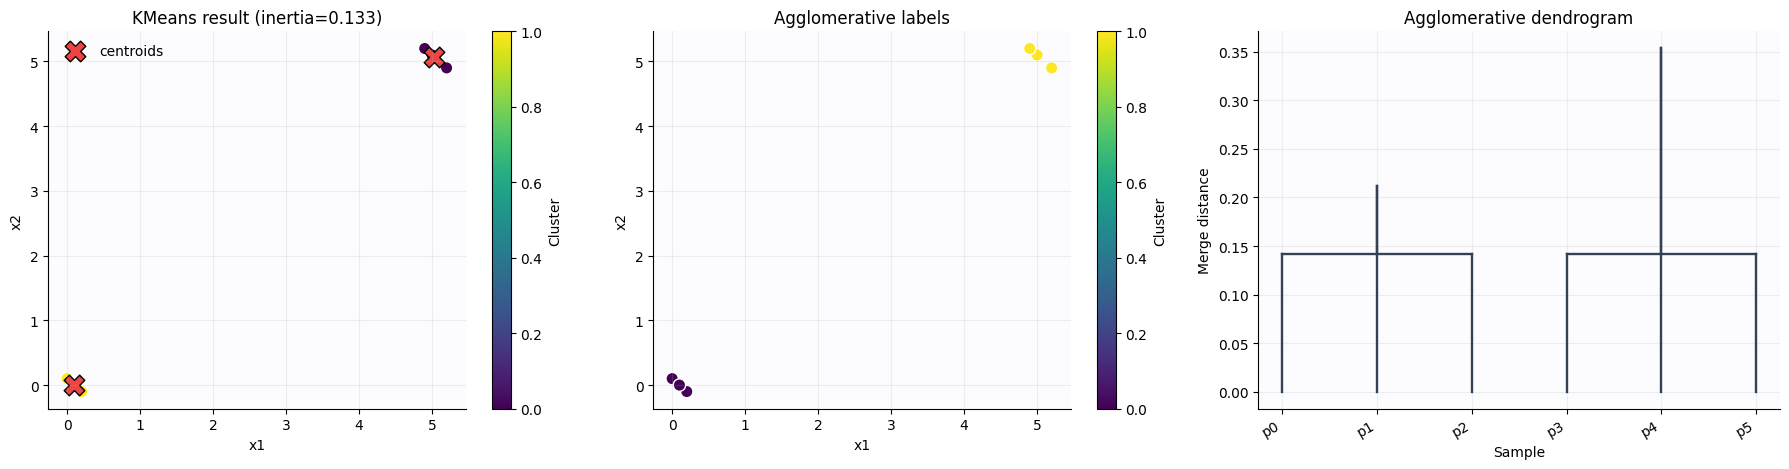

In [8]:
X_cluster = np.array([
    [0.0, 0.1],
    [0.2, -0.1],
    [0.1, 0.0],
    [5.0, 5.1],
    [5.2, 4.9],
    [4.9, 5.2],
])

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X_cluster)

agg = AgglomerativeClustering(n_clusters=2, linkage="average")
agg.fit(X_cluster)

print("KMeans labels:", kmeans.labels_)
print("KMeans centers:\n", np.round(kmeans.cluster_centers_, 3))
print("Agglomerative labels:", agg.labels_)
print("Agglomerative merge distances:", np.round(agg.distances_, 3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
plotting.plot_kmeans_clusters(kmeans, X_cluster, ax=axes[0], feature_names=["x1", "x2"], title="KMeans result")
plotting.plot_agglomerative_clusters(
    agg,
    X_cluster,
    ax=axes[1],
    feature_names=["x1", "x2"],
    title="Agglomerative labels",
)
plotting.plot_agglomerative_dendrogram(
    agg,
    ax=axes[2],
    leaf_labels=[f"p{i}" for i in range(len(X_cluster))],
    title="Agglomerative dendrogram",
)
fig.tight_layout()
plt.show()

## 9. MLP and backpropagation

The MLP section makes the neural network concrete in three different ways:

- a network diagram with signed edge weights
- heatmaps of learned weight matrices
- the learned regression curve and the loss history

first 5 losses: [17.2792, 11.9149, 8.3086, 5.8627, 4.1898]
last 5 losses: [0.0999, 0.0988, 0.0978, 0.0967, 0.0957]
predictions: [-2.802 -1.333  1.092  3.378  4.585]


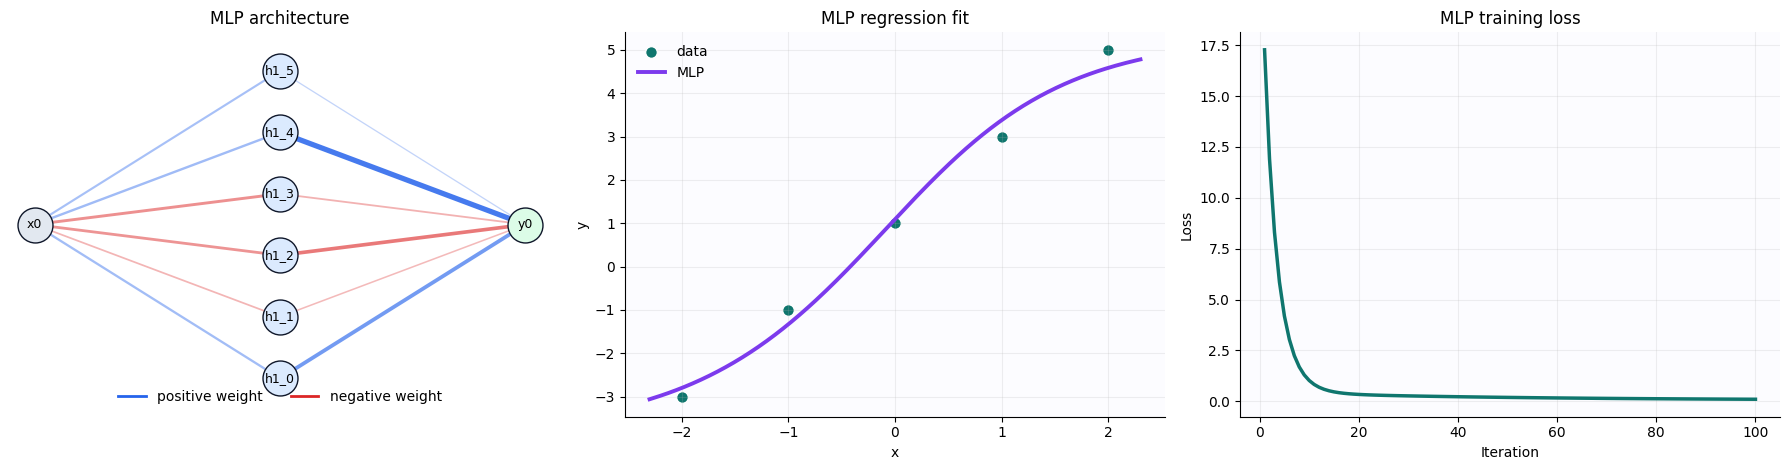

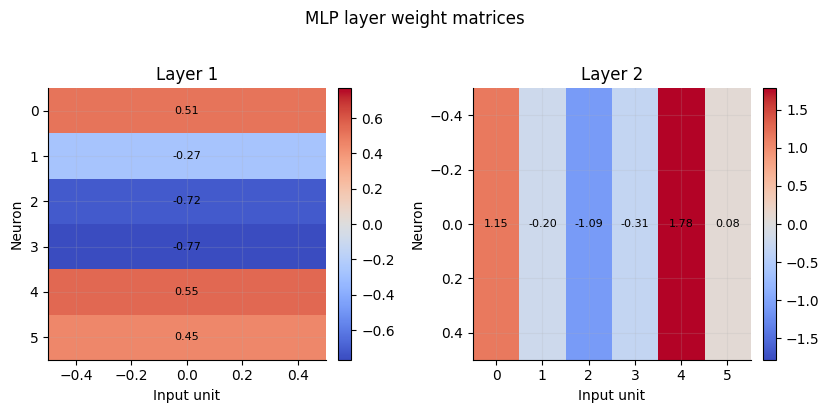

In [9]:
X_nn = np.array([[-2.0], [-1.0], [0.0], [1.0], [2.0]])
y_nn = np.array([-3.0, -1.0, 1.0, 3.0, 5.0])

mlp = MLP(1, [6, 1], seed=0)
history = mlp.fit(X_nn, y_nn, epochs=100, learning_rate=0.03)
nn_predictions = mlp.predict(X_nn)

print("first 5 losses:", [round(value, 4) for value in history[:5]])
print("last 5 losses:", [round(value, 4) for value in history[-5:]])
print("predictions:", np.round(nn_predictions, 3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
plotting.plot_mlp_architecture(mlp, ax=axes[0], title="MLP architecture")
plotting.plot_mlp_predictions(mlp, X_nn, y_nn, ax=axes[1], feature_name="x", target_name="y", title="MLP regression fit")
plotting.plot_loss_curve(history, ax=axes[2], title="MLP training loss")
fig.tight_layout()
plt.show()

plotting.plot_mlp_weight_matrices(mlp, title="MLP layer weight matrices")
plt.show()

## 10. Closing notes

This notebook is intentionally didactic rather than exhaustive. It demonstrates the current Learnify core with visual outputs for every implemented model family.

Typical next directions for the library would include richer optimizers, more losses, tensor-level autodiff, and more advanced neural-network layers.